# Deep Learning Project
## CNN 

|**topic**|**Basic Project**|



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

2026-07-04 14:57:24.058895: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-04 14:57:25.195647: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-04 14:57:29.733310: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0
GPU available: False


2026-07-04 14:57:33.072121: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# CNN - Convolutional Neural Networks
 
### **Core Building Blocks:**
- **Filters/Kernels** - small weight matrices that slide over the image and detect patterns (edges, textures, shapes)
- **Feature Maps** - the output of applying a filter; each map highlights where a pattern was found. 
- **Pooling** - downsamples feature maps (Max/Average Pooling) to reduce size, add translation invariance, and cut computation
- **Architecture** - typically `[Conv -> Activation -> Pool] x N-> Flatten -> Dense -> Softmax`

## 1A. Basic Project - Image classification on Fashion-MNIST
goal classify 28x28 grayscale cloting images into 10 categories. **Skills**: conv2D, MaxPooling2D, feature maps, softmax classification


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Snearker', 'Bag', 'Ankle boot']

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
print('Train shape:', x_train.shape, '| Test shape', x_test.shape)


Train shape: (60000, 28, 28, 1) | Test shape (10000, 28, 28, 1)


In [3]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation ='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation ='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(x_train, y_train, epochs=5,
                    validation_split=0.1, batch_size=128)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f}')

Epoch 1/5


W0000 00:00:1783151182.087478   39724 cpu_allocator_impl.cc:82] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.7735 - loss: 0.6330 - val_accuracy: 0.8557 - val_loss: 0.4005
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8555 - loss: 0.3957 - val_accuracy: 0.8767 - val_loss: 0.3360
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8760 - loss: 0.3400 - val_accuracy: 0.8872 - val_loss: 0.3074
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.8879 - loss: 0.3086 - val_accuracy: 0.8862 - val_loss: 0.2929
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8941 - loss: 0.2890 - val_accuracy: 0.9010 - val_loss: 0.2664

Test Accuracy: 0.8969


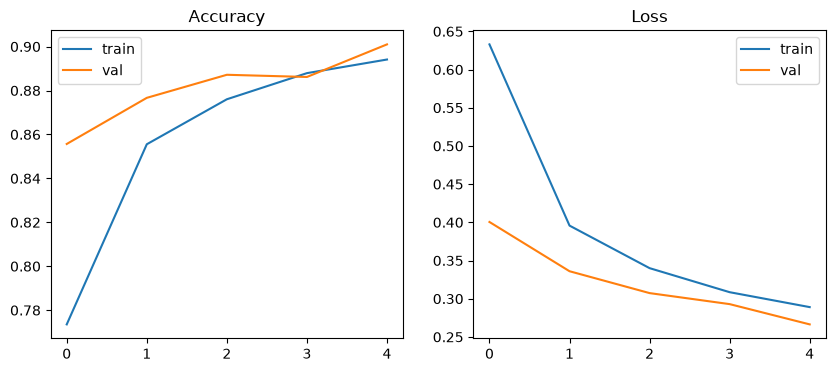

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

# 1b. ADVANCED PROJECT - Feature Map Visualization & Object Detection basics

**Part A:** Visualize what the CNN filters "see" (feature maps).

**Part B:** Object Detection basics - a sliding window / bounding-box concept demo using a pre trained detector.

This teaches how CNNs go from **Classification**(what) to **Detection**(what + where)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


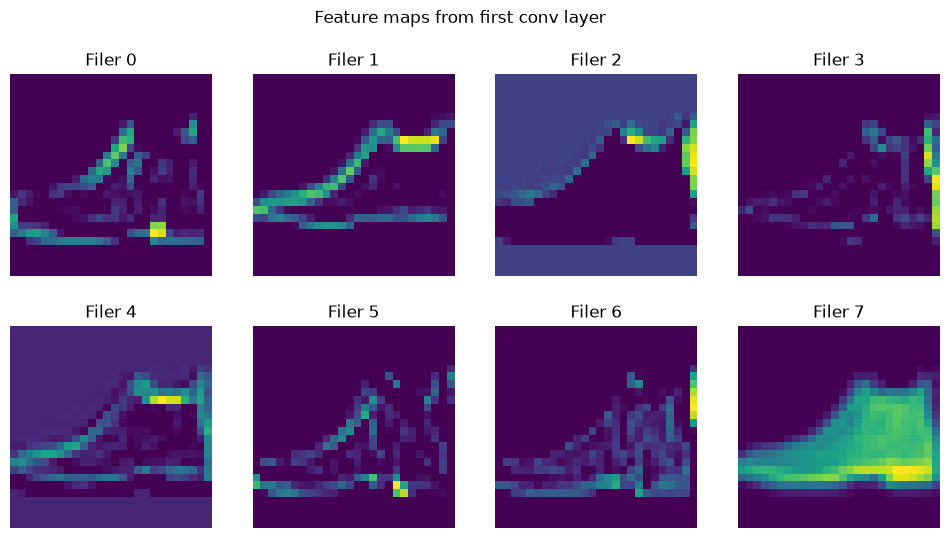

In [6]:
conv_layers = [l.output for l in model.layers if isinstance(l, layers.Conv2D)]
activation_model = keras.Model(inputs=model.inputs, outputs=conv_layers)

sample = x_test[0:1]
activations = activation_model.predict(sample)

first_layer = activations[0][0]
n=8
plt.figure(figsize=(12,6))
for i in range(n):
    plt.subplot(2, 4, i+1)
    plt.imshow(first_layer[:, :, i], cmap='viridis')
    plt.title(f'Filer {i}')
    plt.axis('off')

plt.suptitle('Feature maps from first conv layer')
plt.show()

In [ ]:
import sys
import importlib.util

import tensorflow_hub as hub
from PIL import Image

detector = hub.load('https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2')

def detect_objects(img_path):
    img = Image.open(img_path).convert('RGB')
    img_arr = np.array(img)
    inp = tf.convert_to_tensor(img_arr[np.newaxis, ...], dtype=tf.uint8)
    result = detector(inp)
    boxes = result['detection_boxes'][0].numpy()
    scores = result['detection_scores'][0].numpy()

    plt.figure(figsize=(8,8))
    plt.imshow(img_arr)
    h, w = img_arr.shape[:2]
    for box, score in zip(boxes, scores):
        if score < 0.4:
            continue
        y1, x1, y2, x2 = box
        rect = plt.Rectangle((x1 * w, y1 * h), (x2 - x1) * w, (y2 - y1)*h,
                             fill = False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x1 * w, y1 * h, f'{score:.2f}', color='white',
                 bbox=dict(facecolor='red'))
    plt.axis('off')
    plt.show()
    print(f'Detector loaded. Call detect_objects("path/to/image.jpg")')

In [ ]:
import keras_hub
from PIL import Image




def detect_objects(img_path):
    # 2. Standardize image loading using PIL
    img = Image.open(img_path).convert('RGB')
    img_arr = np.array(img)
    
    # 3. Keras Hub accepts raw numpy arrays/tensors cleanly
    # We expand dimensions to create a batch: (1, height, width, 3)
    batch_input = np.expand_dims(img_arr, axis=0)
    
    # 4. Run inference
    result = detector.predict(batch_input)
    
    # 5. Extract prediction outputs from the structured Keras Hub dictionary
    # Coordinates come out in relative (0 to 1) format based on bounding_box_format choice
    boxes = result['boxes'][0]       
    confidence = result['confidence'][0]
    
    # 6. Set up the visualization plot
    plt.figure(figsize=(8, 8))
    plt.imshow(img_arr)
    h, w = img_arr.shape[:2]
    
    for box, score in zip(boxes, confidence):
        # Filter low confidence predictions
        if score < 0.4:
            continue
            
        y1, x1, y2, x2 = box
        
        # Calculate pixel dimensions for drawing matching original logic
        box_w = (x2 - x1) * w
        box_h = (y2 - y1) * h
        
        # Create and overlay the rectangle boundary
        rect = plt.Rectangle((x1 * w, y1 * h), box_w, box_h,
                             fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label the box with the accuracy metric
        plt.text(x1 * w, y1 * h, f'{score:.2f}', color='white',
                 bbox=dict(facecolor='red', alpha=0.6))
                 
    plt.axis('off')
    plt.show()

print('Detector loaded. Call detect_objects("path/to/image.jpg")')


Detector loaded. Call detect_objects("path/to/image.jpg")


# RNN - Recurrent Neural Networks (LSTM & GRU)

RNNs process sequential data (text, time series, audio) by keeping a hidden state that carries memory across time steps.

- **LSTM (Long Short-Term Memory):** uses input/forget/output gates to remmember long range dependencies and avoid vanishing gradients.

- **GRU (Gated Recurrent Unit):** a lighter variant with reset/update gates - fewer parameters, often trains faster.

# 2A. Basic Project - Sentiment Analysis with LSTM (IMDB reviews)

**Goal** classify movie reviews as positive/ negative from text sequences

In [2]:
vocab_size = 10000
max_len = 200
(xt, yt), (xv, yv) = keras.datasets.imdb.load_data(num_words=vocab_size)
xt = keras.preprocessing.sequence.pad_sequences(xt, maxlen=max_len)
xv = keras.preprocessing.sequence.pad_sequences(xv, maxlen=max_len)
print(f'Train: {xt.shape} | Test: {xv.shape}')


Train: (25000, 200) | Test: (25000, 200)


In [9]:
lstm_model = keras.models.Sequential([
    layers.Embedding(vocab_size, 64, input_length=max_len),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

lstm_model.fit(xt, yt, epochs=3, batch_size=128, validation_split=0.2)
print('Test accuracy:', lstm_model.evaluate(xv, yv, verbose=0)[1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - accuracy: 0.7350 - loss: 0.5172 - val_accuracy: 0.8512 - val_loss: 0.3523
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 250ms/step - accuracy: 0.8878 - loss: 0.2867 - val_accuracy: 0.8698 - val_loss: 0.3196
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9240 - loss: 0.2045 - val_accuracy: 0.8674 - val_loss: 0.3292
Test accuracy: 0.8630800247192383


In [22]:
t = np.arange(0, 2000)
series = np.sin(0.02 * t) + 0.5 * np.sin(0.05 * t) + 0.1 * np.random.randn(len(t))

def make_windows(data, in_steps = 50, out_steps = 10):
    X, Y = [], []
    for i in range(len(data) - in_steps - out_steps):
        X.append(data[i:i+in_steps])
        Y.append(data[i+in_steps:i+in_steps+out_steps])
    return np.array(X)[..., np.newaxis], np.array(Y) 

IN, OUT = 50 , 10 
X, Y = make_windows(series, IN, OUT)
split = int(0.8 * len(X))
Xtr, Ytr, Xte, Yte = X[:split], Y[:split], X[split:], Y[split:]
print(f'X {X.shape} | Y {Y.shape}')


X (1940, 50, 1) | Y (1940, 10)


In [25]:
gru_model = keras.Sequential([
    layers.Input(shape=(IN, 1)),
    layers.GRU(64, return_sequences = True),
    layers.GRU(32),
    layers.Dense(OUT)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(Xtr, Ytr, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.3902 - val_loss: 0.1485
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0806 - val_loss: 0.0686
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0559 - val_loss: 0.0516
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0474 - val_loss: 0.0446
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0416 - val_loss: 0.0391
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0358 - val_loss: 0.0323
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0293 - val_loss: 0.0247
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0246 - val_loss: 0.0215
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0227 - val_loss: 0.0204
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0216 - val_loss: 0.0196


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


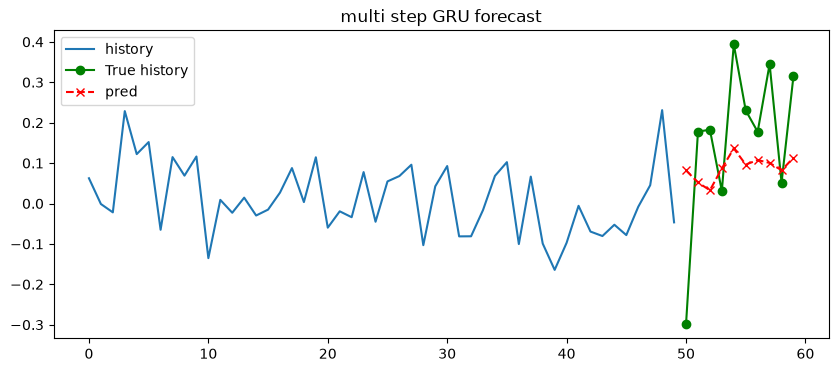

In [28]:
idx = 0
pred = gru_model.predict(Xte[idx:idx + 1])[0]
plt.figure(figsize=(10,4))
plt.plot(range(IN), Xte[idx].ravel(), label='history'),
plt.plot(range(IN, IN+OUT), Yte[idx], 'g-o', label='True history'),
plt.plot(range(IN, IN+OUT), pred, 'r--x',label='pred')
plt.legend()
plt.title('multi step GRU forecast')
plt.show()
